In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded = files.upload()  # A button will appear — click and select your CSV

import pandas as pd
import io
df = pd.read_csv(io.BytesIO(uploaded['Sample - Superstore.csv']), encoding='latin-1')
print(df.head())

Saving Sample - Superstore.csv to Sample - Superstore.csv
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Produc

In [7]:
print(df.shape)        # rows and columns
print(df.head())       # first 5 rows
print(df.info())       # data types
print("Missing Values:")
print(df.isnull().sum())  # check missing values
print(df.describe())   # statistics

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

This Dataset has 9994 Rows and 21 Columns.
There is no missing values.

Which Category has the Highest Sales ?

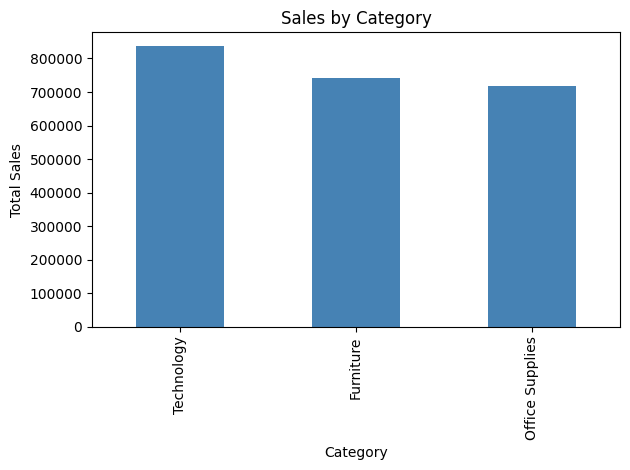

In [8]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar', color='steelblue', title='Sales by Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('category_sales.png')
plt.show()

Which Region Performs Best?

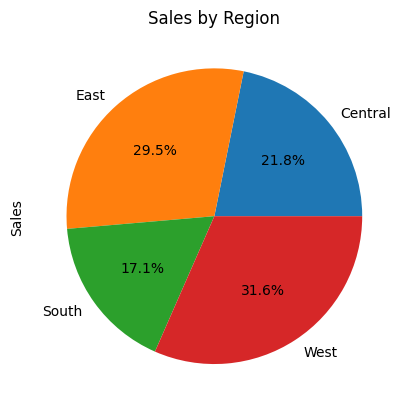

In [9]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='pie', autopct='%1.1f%%', title='Sales by Region')
plt.savefig('region_sales.png')
plt.show()

What is the Monthly Sales Trend?

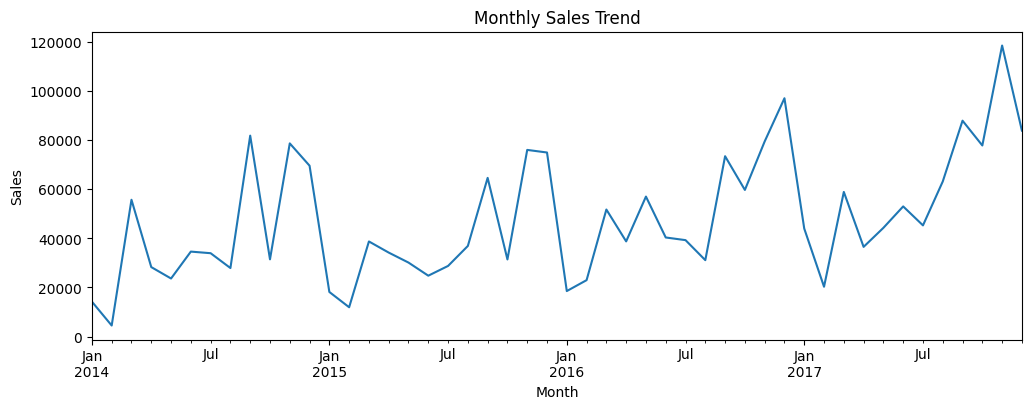

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
monthly = df.groupby('Month')['Sales'].sum()
monthly.plot(title='Monthly Sales Trend', figsize=(12,4))
plt.ylabel('Sales')
plt.savefig('monthly_trend.png')
plt.show()

Is there a relationship between Discount and Profit?

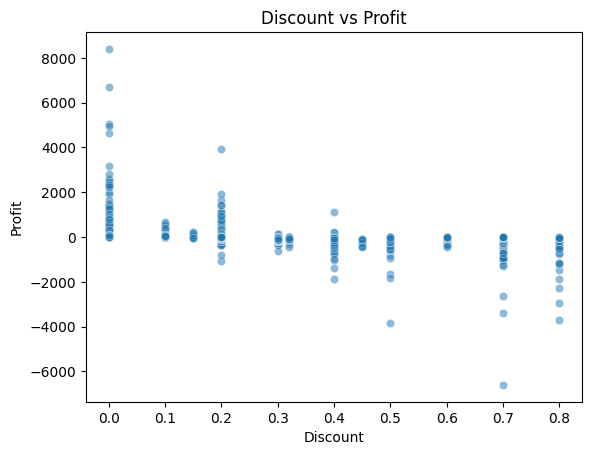

In [11]:
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5)
plt.title('Discount vs Profit')
plt.savefig('discount_profit.png')
plt.show()

Top 10 products by sales?

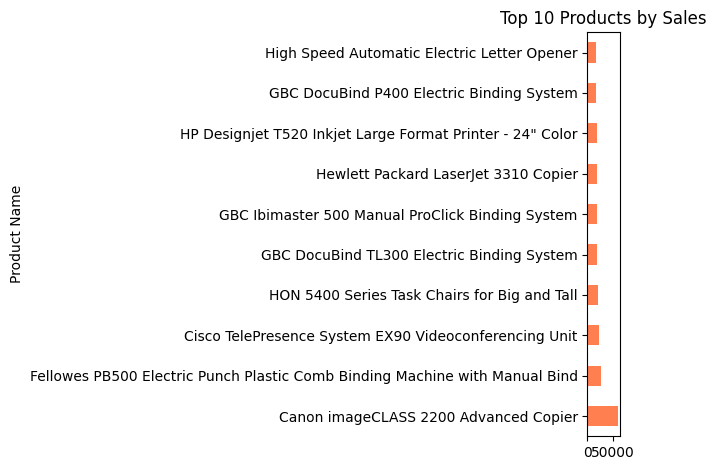

In [12]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
top_products.plot(kind='barh', title='Top 10 Products by Sales', color='coral')
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

KEY FINDINGS:
1. Technology category generates the highest revenue among all categories
2. The West region contributes the most to overall sales (31.6%)
3. Sales are growing year-over-year with strong seasonal peaks in Q4
4. High discounts (above 40%) consistently result in losses — discount strategy needs revision
5. Office technology products (copiers, binding systems) are the top revenue drivers